# Expressing Attention

This notebook writes scaled dot-product attention as a morphism and draws it as a neural circuit diagram. It then derives the training step of the attention. The training step is a forward pass, which saves the values the backward pass reads, followed by the backward pass, which returns the gradients of the queries, the keys and the values. The last cell writes a page that switches between the attention and its training step.

*Written by Claude Opus 5.5 (1M context) at reasoning effort 40, 2026-09-27.*

In [1]:
import dataclasses

import notebooks.website.tutorial.derive_training_step as derive_training_step
import notebooks.display.notebook_diagrams as notebook_diagrams
import notebooks.website.tutorial.express_attention as express_attention
import notebooks.website.tutorial.tutorial_pages as tutorial_pages
import notebooks.website.website_output as website_output

DIAGRAMS = notebook_diagrams.DiagramSettings(
    mode=notebook_diagrams.DiagramMode.INLINE,
    dark_mode=notebook_diagrams.ColorMode.LIGHT,
    advanced_display=notebook_diagrams.AdvancedDisplay.LEGEND,
    operator_explanations=express_attention.OPERATOR_EXPLANATIONS,
    operator_references=express_attention.OPERATOR_REFERENCES,
    operator_roles=express_attention.SINGLE_HEAD_ROLES,
    reindexing_explanations=express_attention.REINDEXING_EXPLANATIONS,
    title='Scaled Dot-Product Attention')
PAGE = dataclasses.replace(
    DIAGRAMS, mode=notebook_diagrams.DiagramMode.HTML,
    advanced_display=notebook_diagrams.AdvancedDisplay.INTERACTIVE,
    page_directory=website_output.TUTORIAL_PAGES)

ATTENTION = express_attention.scaled_dot_product_attention()
TRAINING_STEP = derive_training_step.derive_training_step(ATTENTION)

## Scaled dot-product attention

Attention reads a query for each position of the axis $q$, and a key and a value for each position of the axis $x$. A query and a key hold $|d|$ channels each, where $|d|$ is the size of the axis $d$, and a value holds $|v|$ channels. Each query takes the dot product with every key, which gives one score for each pair of a query and a key. The scores are multiplied by $|d|^{-1/2}$. A softmax over the keys turns the scores of each query into weights that sum to one, and the result for each query is the sum of the values under its weights.

$$\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\left(\frac{Q K^{\top}}{\sqrt{|d|}}\right) V$$

The scale keeps the spread of the scores from growing with the number of channels. Without the scale, the softmax of a query with many channels gives almost all of the weight to one key, and the gradients of the softmax are then small, as Section 3.2.1 of [Attention Is All You Need](https://arxiv.org/pdf/1706.03762v7) states.

The figure draws every axis of an array as one wire labelled with the name of the axis, and a dashed line separates two arrays that travel side by side. An operation is broadcast over the axes whose wires cross it, which means that it computes the same function at every index of those axes. An operation consumes the axes whose wires end at it. The dot product joins the two $d$ wires with a cup, because it sums over $d$, and the $q$ and $x$ wires cross it into the scores. The scale is drawn as the formula it applies to every score. The softmax is the triangle. It consumes the $x$ wire and writes it again, and the $q$ wire crosses it, because the scores of each query are normalised on their own. The weighted sum joins the $x$ wire of the weights and the $x$ wire of the values with a cup. The coloured box is a block, which groups the operations under the title of the mechanism, and the table beside the figure gives the name each axis has in code.

Scaled dot-product attention. The cup on d is the dot product, the triangle is the softmax over the keys, and the cup on x is the weighted sum of the values.


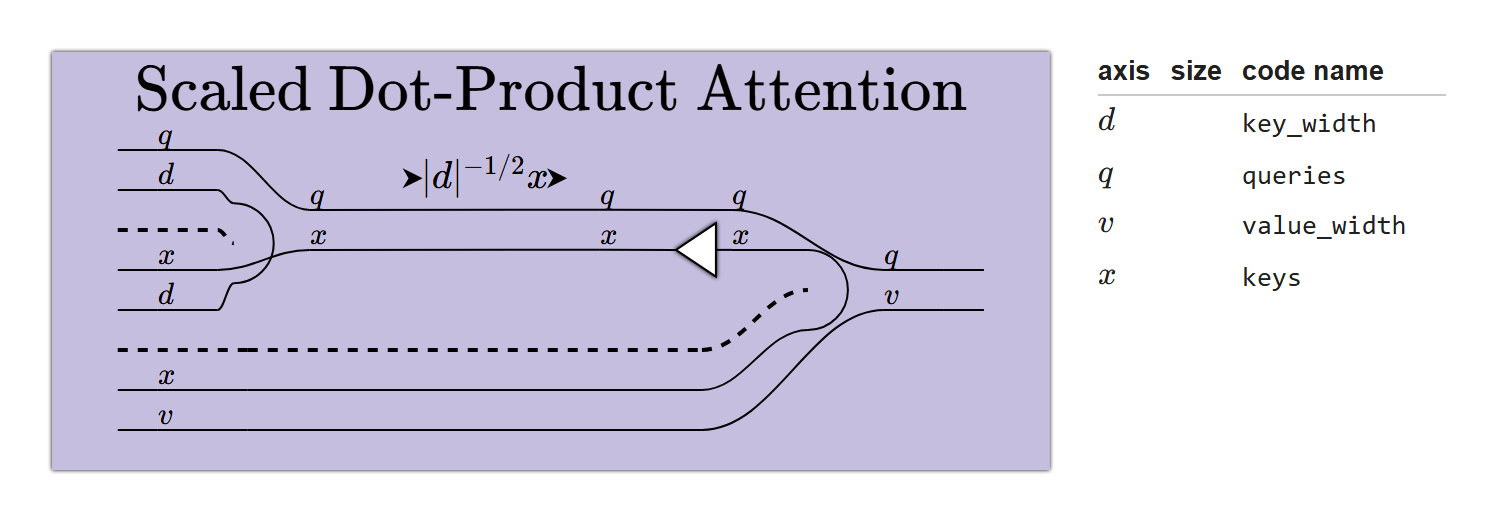

In [2]:
await notebook_diagrams.show_diagram(
    ATTENTION,
    'Scaled dot-product attention. The cup on d is the dot product, the triangle is '
    'the softmax over the keys, and the cup on x is the weighted sum of the values.',
    width=900, settings=DIAGRAMS)

## Writing the softmax out and moving its division past the weighted sum

The softmax of the scores $s$ of one query is $e^{s}$ divided by $\sum_{i_{x} \in x} e^{s[i_{x}]}$. The derivation needs the derivative of every operation, so the softmax is first written out as an exponential, a sum over $x$, a reciprocal and a product. The weighted sum multiplies the value of every key by the same reciprocal, so the product with the reciprocal can move past the weighted sum. In the figure the weighted sum reads the exponentials directly, and the reciprocal scales the result of each query at $[q, v]$ in place of the weights at $[q, x]$. The weights of the softmax are therefore never written as an array. FlashAttention computes attention in the same order, and the rewritten attention computes the same result as the attention above.

The softmax written out as an exponential, a sum over the keys, a reciprocal and a product, with the product moved past the weighted sum.


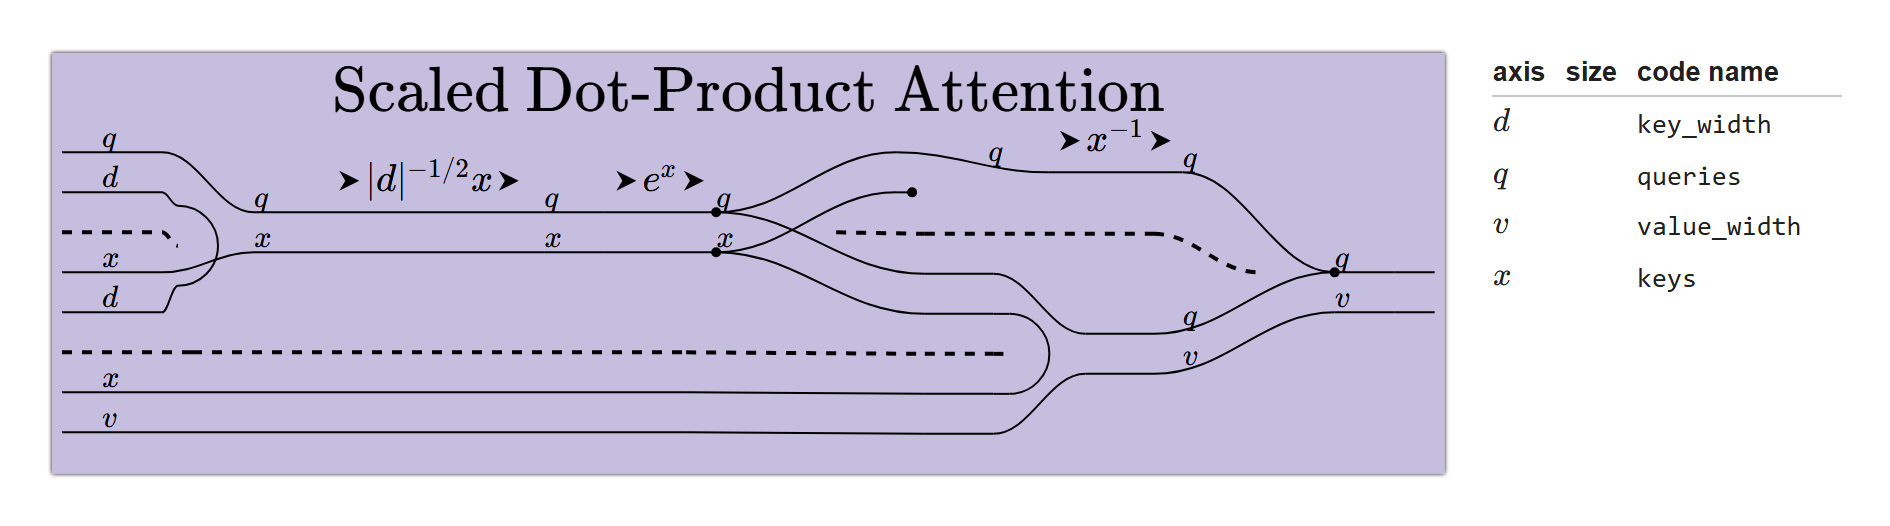

In [3]:
await notebook_diagrams.show_diagram(
    TRAINING_STEP.prepared,
    'The softmax written out as an exponential, a sum over the keys, a reciprocal and '
    'a product, with the product moved past the weighted sum.',
    width=1200, settings=DIAGRAMS)

## Deriving the training step

The derivation turns the rewritten attention into two passes. The forward pass computes the attention and saves to a tape every value the backward pass reads. The backward pass reads $\mathrm{d}O$, the gradient of the loss with respect to the output, and returns $\mathrm{d}Q$, $\mathrm{d}K$ and $\mathrm{d}V$, the gradients with respect to the three inputs. The tape is the only thing the two passes share. Each operation declares the values its derivative reads, and a simplification after the derivation removes the values the backward pass can compute from other saved values.

The simplification leaves the exponentials of the scores on the tape, one number for every pair of a query and a key. The backward pass reads them to form the gradient of the scores and the gradient of the values. The queries and the keys are on the tape already, so the derivation deletes the slot of the exponentials, and the backward pass takes the dot products of the queries with the keys again, scales them and takes their exponentials. The backward pass then computes one more product of the queries with the keys, and no saved array holds a number for every pair of a query and a key. FlashAttention saves the same arrays and recomputes the scores in its backward pass in the same way. The paragraph on recomputation in Section 3.1 of [FlashAttention](https://arxiv.org/pdf/2205.14135v2) states that the output and the statistics of the softmax are stored, and that the scores and the probabilities are recomputed in the backward pass from the queries, the keys and the values. The paper was read on 2026-09-27. The forward pass saves five arrays, which are the queries at $[q, d]$, the keys at $[x, d]$, the values at $[x, v]$, the reciprocals of the row sums at $[q]$ and the output at $[q, v]$.

The backward pass computes the row statistic of FlashAttention, $D[i_{q}] = \sum_{i_{v} \in v} \mathrm{d}O[i_{q}, i_{v}]\, O[i_{q}, i_{v}]$, from the saved output and its gradient. The scale appears in both passes. The forward pass multiplies the scores by $|d|^{-1/2}$. The backward pass multiplies the rebuilt scores by the same number, and it multiplies the gradient of the scaled scores by it as well. Multiplying by a constant is linear, so its derivative reads nothing from the tape.

The figure stacks the forward pass over the backward pass, with a double dashed line between them. An arrow leaving an operation downwards is a drop, which saves the value on its wire to the slot named beside it. An arrow entering an operation from above is a grab, which reads a slot. The backward pass is drawn mirrored, so it runs from $\mathrm{d}O$ on the right to $\mathrm{d}Q$, $\mathrm{d}K$ and $\mathrm{d}V$ on the left, and each gradient leaves the figure at the end where its input entered. The block of the forward pass has a counterpart in the backward pass titled $R[\ldots]$, which is the reverse derivative of the block. Both passes compile to PyTorch, and on random inputs the backward pass returns the gradients that `torch.autograd` computes for the same attention written directly in PyTorch.

The training step. The forward pass saves five arrays to the tape, and the backward pass rebuilds the exponentials of the scores from the queries and the keys and returns the gradients of Q, K and V.


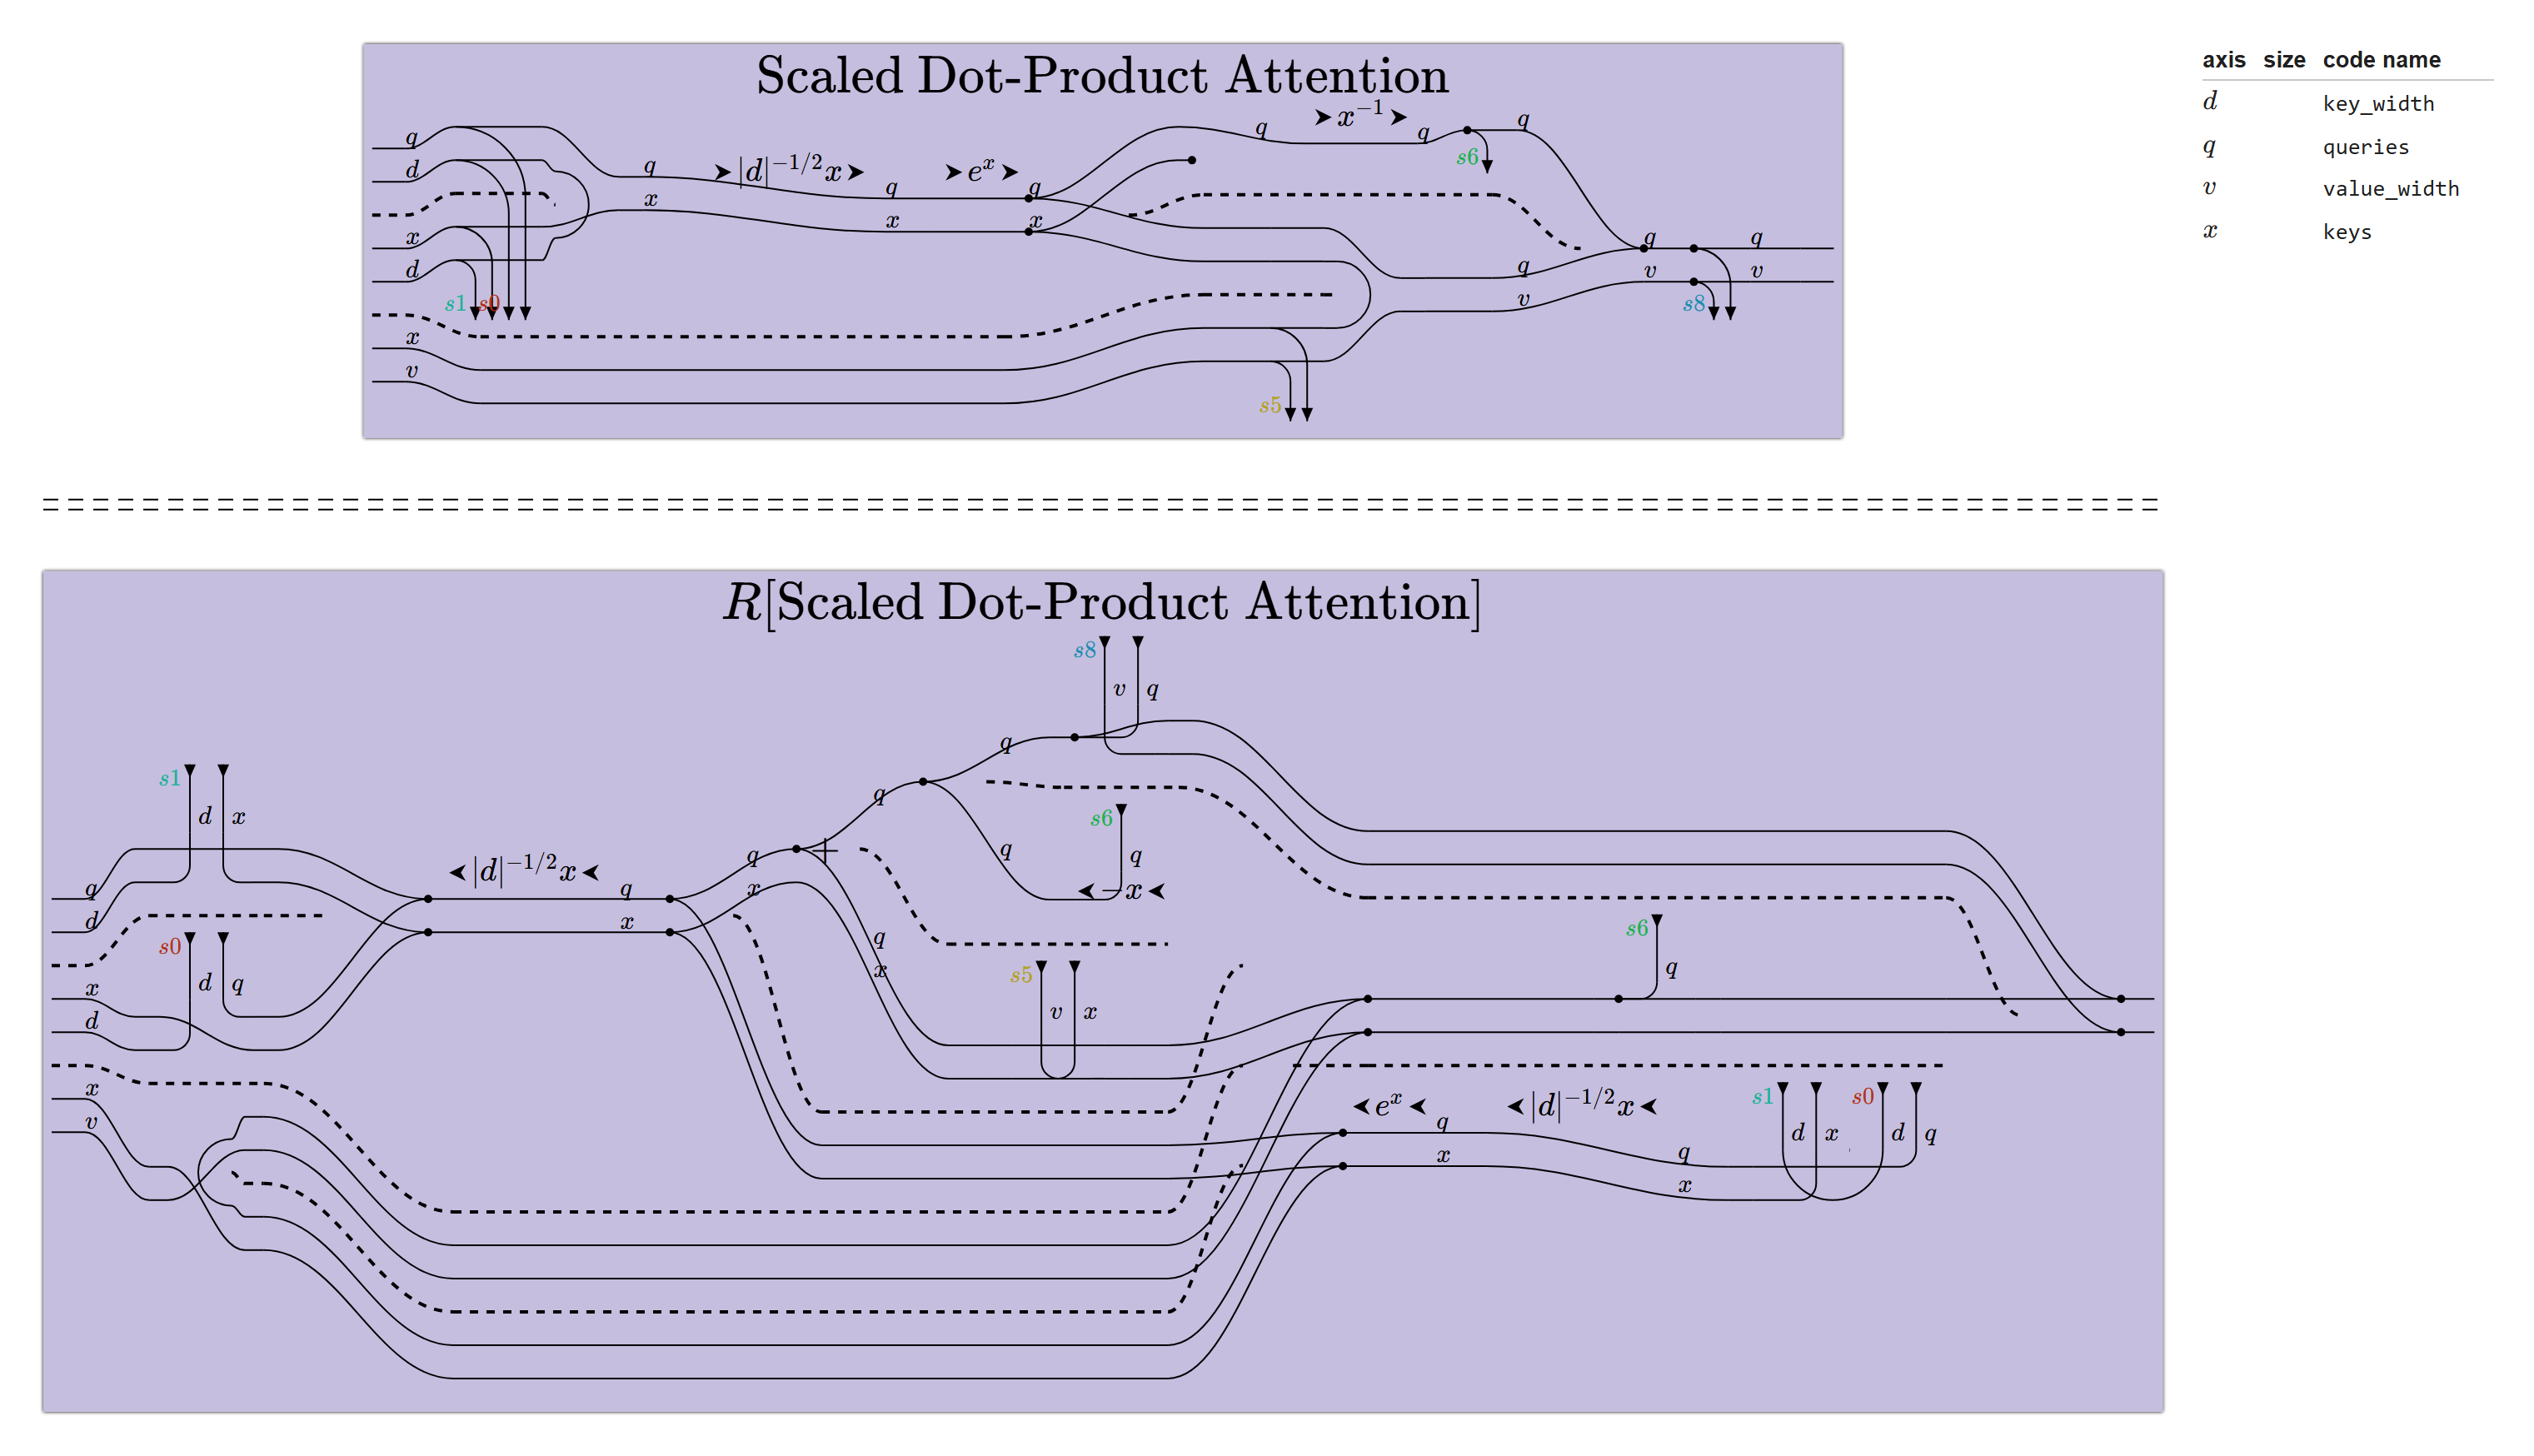

In [4]:
await notebook_diagrams.show_diagram(
    TRAINING_STEP.forward_over_backward(),
    'The training step. The forward pass saves five arrays to the tape, and the '
    'backward pass rebuilds the exponentials of the scores from the queries and the '
    'keys and returns the gradients of Q, K and V.',
    width=1400, settings=DIAGRAMS)

## The interactive page

The last cell writes the attention and its training step to `notebooks/website/output/tutorial/Attention/index.html`, one file that opens with no server and no network. The selector on the page switches between the forward pass and the training step, and the buttons on the page switch the form of the drawing and its theme. Resting the pointer on the block opens a box with its title, its formula and its description. Resting it on the softmax opens the softmax written out, and resting it on the scale opens the formula of the scale.

In [5]:
await notebook_diagrams.show_page_variants(
    tutorial_pages.attention_page(ATTENTION, TRAINING_STEP, PAGE),
    'Scaled dot-product attention and its training step as one HTML file.',
    settings=PAGE, slug=tutorial_pages.ATTENTION_SLUG, initial=tutorial_pages.FORWARD)

Scaled dot-product attention and its training step as one HTML file.


(written to notebooks/website/output/tutorial/Attention/)
